In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=8,3
sns.set_theme(style="whitegrid", palette="dark")

In [2]:
weather=pd.read_csv(r'C:\Users\admin\Downloads\archive\weatherHistory.csv')

In [3]:
weather

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [4]:
weather.shape

(96453, 12)

In [5]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [6]:
weather.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [7]:
weather.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [8]:
len(weather.columns)

12

In [9]:
weather.columns=['Formatted_Date', 'Summary', 'Precip_Type', 'Temperature','Apparent_Temperature', 'Humidity', 'Wind_Speed', 'Wind_Bearing', 'Visibility', 'Loud_Cover','Pressure', 'Daily_Summary']

In [10]:
weather['Precip_Type'] = weather['Precip_Type'].fillna('Unknown')

In [11]:
weather.isnull().sum()

Formatted_Date          0
Summary                 0
Precip_Type             0
Temperature             0
Apparent_Temperature    0
Humidity                0
Wind_Speed              0
Wind_Bearing            0
Visibility              0
Loud_Cover              0
Pressure                0
Daily_Summary           0
dtype: int64

In [12]:
weather.dtypes

Formatted_Date           object
Summary                  object
Precip_Type              object
Temperature             float64
Apparent_Temperature    float64
Humidity                float64
Wind_Speed              float64
Wind_Bearing            float64
Visibility              float64
Loud_Cover              float64
Pressure                float64
Daily_Summary            object
dtype: object

In [13]:
weather.describe()

,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Loud_Cover,Pressure
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [14]:
weather.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Temperature,96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
Apparent_Temperature,96453.0,10.855029,10.696847,-27.716667,2.311111,12.0000,18.838889,39.344444
Humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
Wind_Speed,96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
Wind_Bearing,96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility,96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud_Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure,96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


In [15]:
weather.head()

,Formatted_Date,Summary,Precip_Type,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Loud_Cover,Pressure,Daily_Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


<Axes: xlabel='Temperature', ylabel='Density'>

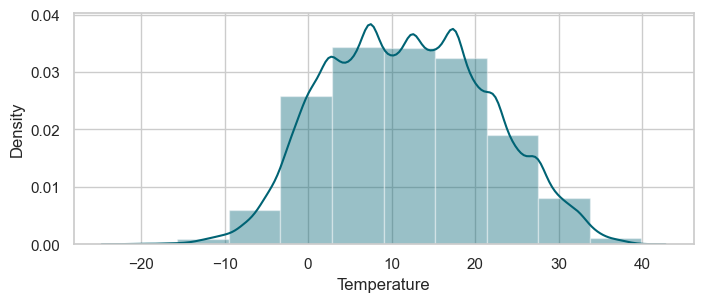

In [16]:
sns.distplot(weather.Temperature,color='c',bins=10)

<Axes: xlabel='Apparent_Temperature', ylabel='Density'>

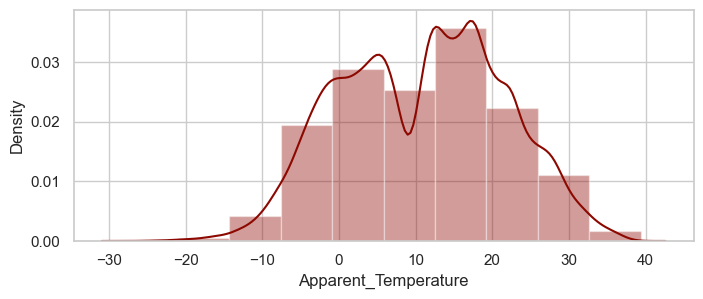

In [17]:
sns.distplot(weather.Apparent_Temperature,color='r',bins=10)

<Axes: xlabel='Humidity', ylabel='Density'>

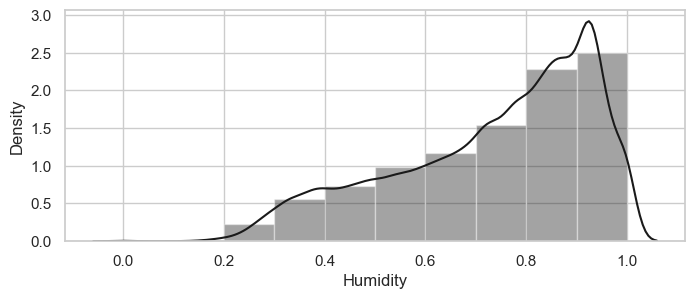

In [18]:
sns.distplot(weather.Humidity,color='k',bins=10)

<Axes: xlabel='Wind_Speed', ylabel='Density'>

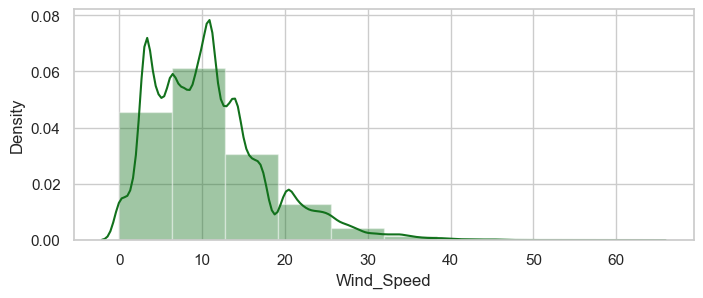

In [19]:
sns.distplot(weather.Wind_Speed,color='g',bins=10)

<Axes: xlabel='Wind_Speed', ylabel='Density'>

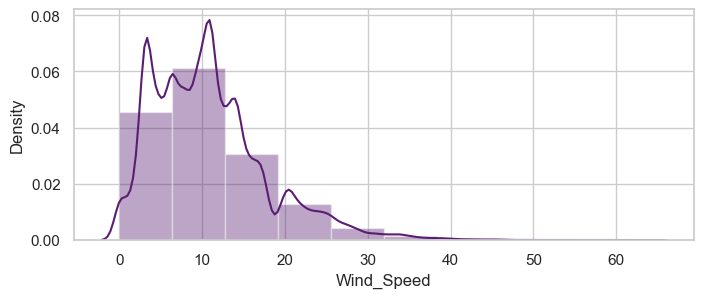

In [20]:
sns.distplot(weather.Wind_Speed,color='m',bins=10)

<Axes: xlabel='Wind_Bearing', ylabel='Density'>

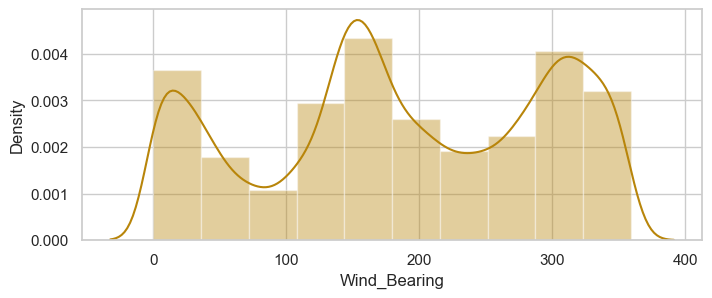

In [21]:
sns.distplot(weather.Wind_Bearing,color='y',bins=10)

<Axes: xlabel='Visibility', ylabel='Density'>

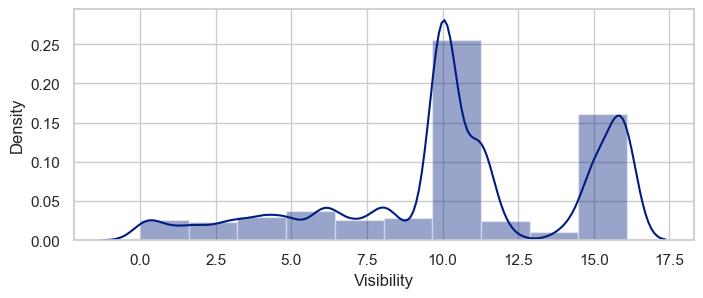

In [22]:
sns.distplot(weather.Visibility,color='b',bins=10)

<Axes: xlabel='Pressure', ylabel='Density'>

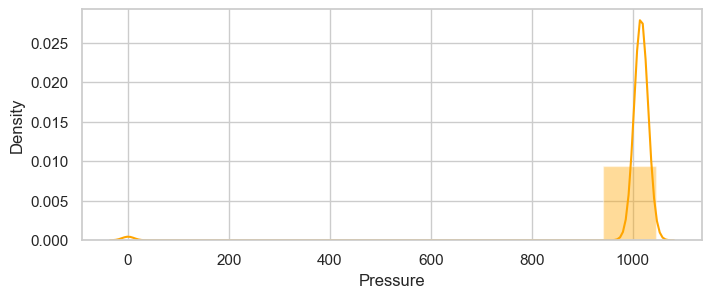

In [23]:
sns.distplot(weather.Pressure,color='orange',bins=10)

In [24]:
weather.head()

,Formatted_Date,Summary,Precip_Type,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Loud_Cover,Pressure,Daily_Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


<Axes: xlabel='Precip_Type', ylabel='count'>

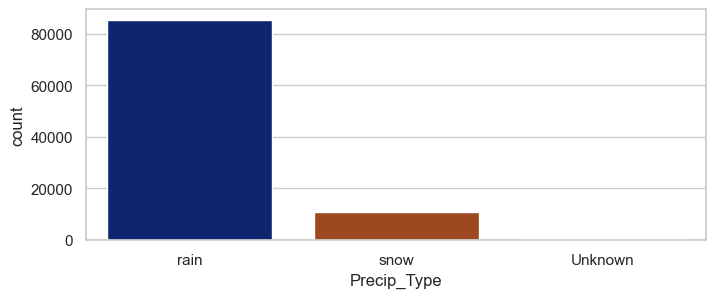

In [25]:
sns.countplot(data=weather,x='Precip_Type',palette='dark')

<Axes: xlabel='Precip_Type', ylabel='count'>

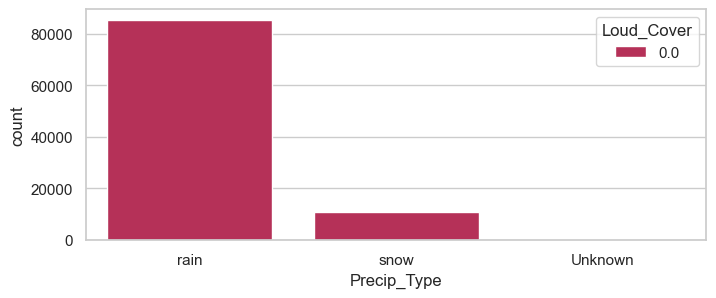

In [26]:
sns.countplot(data=weather,x='Precip_Type',palette='rocket',hue='Loud_Cover')

In [27]:
weather.head()

,Formatted_Date,Summary,Precip_Type,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Loud_Cover,Pressure,Daily_Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


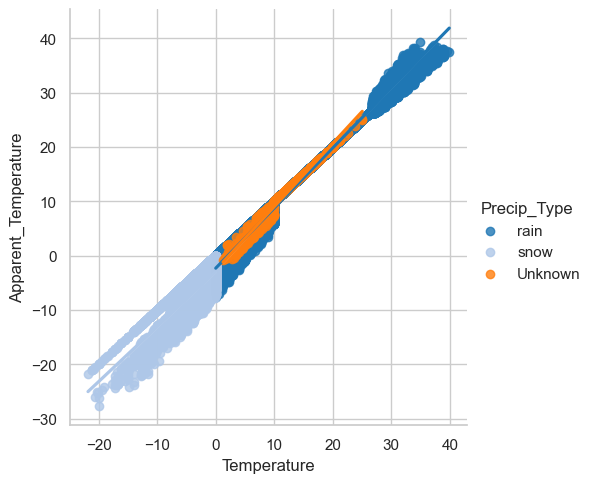

In [28]:
sns.lmplot(data=weather,x='Temperature',y='Apparent_Temperature',hue='Precip_Type',palette='tab20')

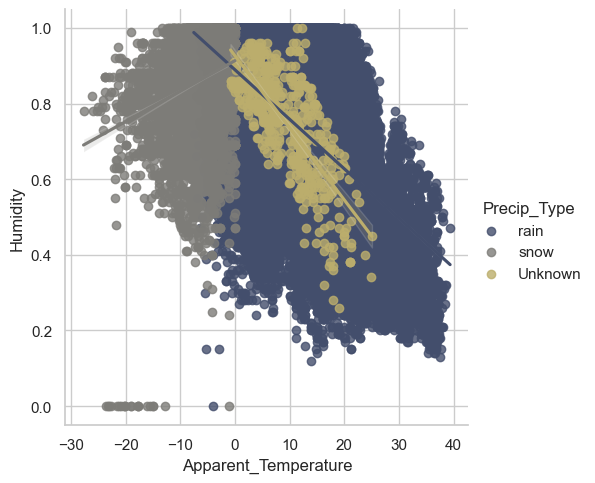

In [29]:
sns.lmplot(data=weather,x='Apparent_Temperature',y='Humidity',hue='Precip_Type',palette='cividis')

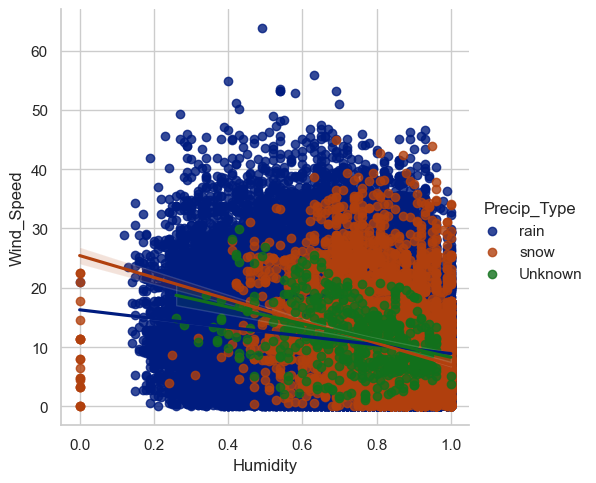

In [30]:
sns.lmplot(data=weather,x='Humidity',y='Wind_Speed',hue='Precip_Type',palette='dark')

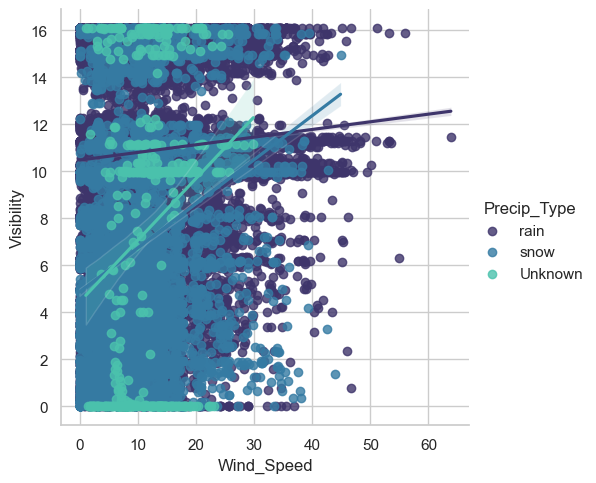

In [31]:
sns.lmplot(data=weather,x='Wind_Speed',y='Visibility',hue='Precip_Type',palette='mako')

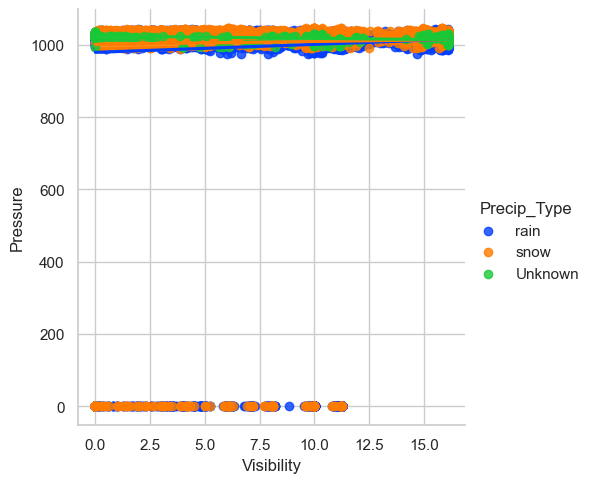

In [32]:
sns.lmplot(data=weather,x='Visibility',y='Pressure',hue='Precip_Type',palette='bright')

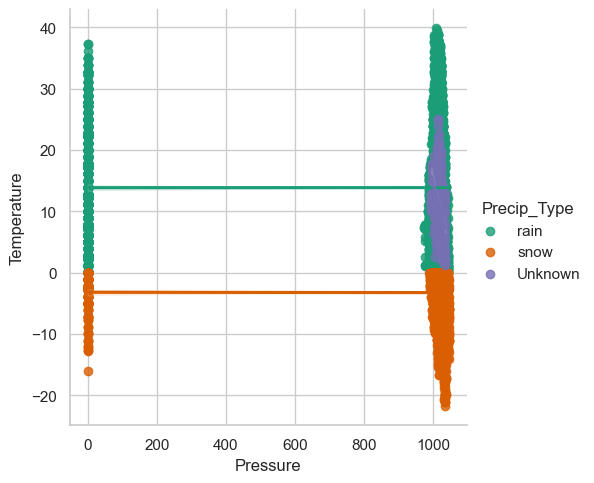

In [33]:
sns.lmplot(data=weather,x='Pressure',y='Temperature',hue='Precip_Type',palette='Dark2')

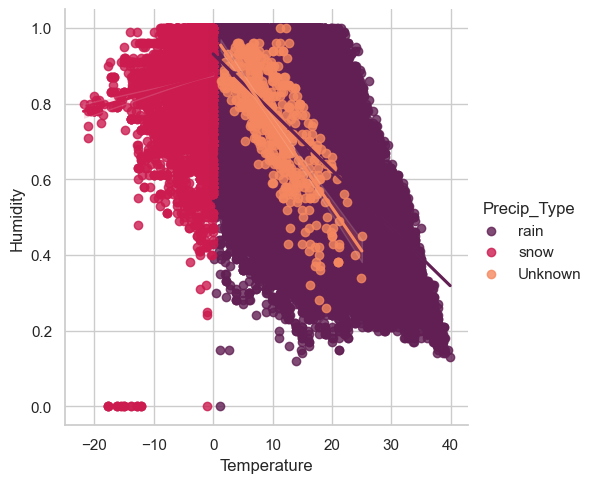

In [34]:
sns.lmplot(data=weather,x='Temperature',y='Humidity',hue='Precip_Type',palette='rocket')

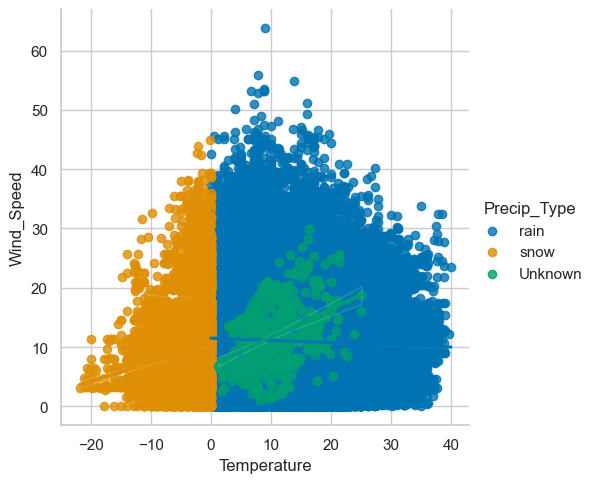

In [35]:
sns.lmplot(data=weather,x='Temperature',y='Wind_Speed',hue='Precip_Type',palette='colorblind')

In [36]:
weather.head()

,Formatted_Date,Summary,Precip_Type,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Loud_Cover,Pressure,Daily_Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


<Axes: xlabel='Precip_Type', ylabel='Temperature'>

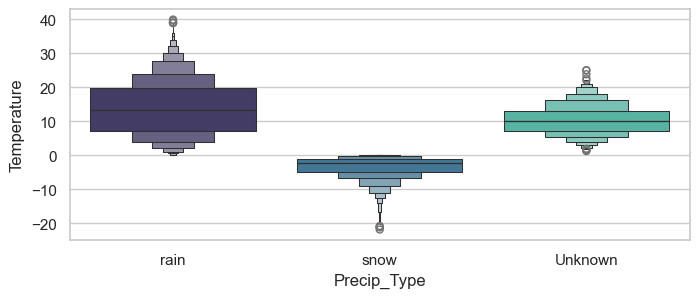

In [37]:
sns.boxenplot(data=weather,x='Precip_Type',y='Temperature',palette='mako')

<Axes: xlabel='Precip_Type', ylabel='Apparent_Temperature'>

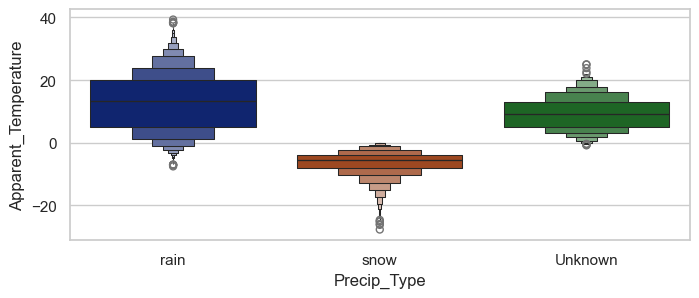

In [38]:
sns.boxenplot(data=weather,x='Precip_Type',y='Apparent_Temperature',palette='dark')

<Axes: xlabel='Precip_Type', ylabel='Humidity'>

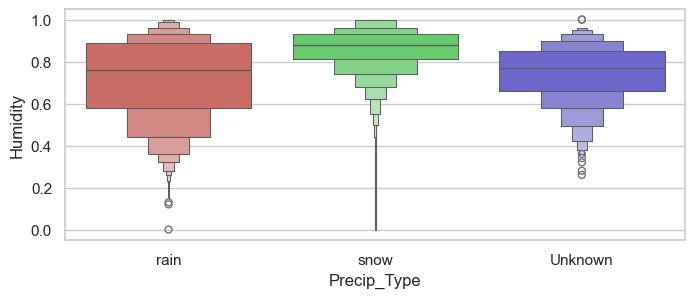

In [39]:
sns.boxenplot(data=weather,x='Precip_Type',y='Humidity',palette='hls')

<Axes: xlabel='Precip_Type', ylabel='Wind_Bearing'>

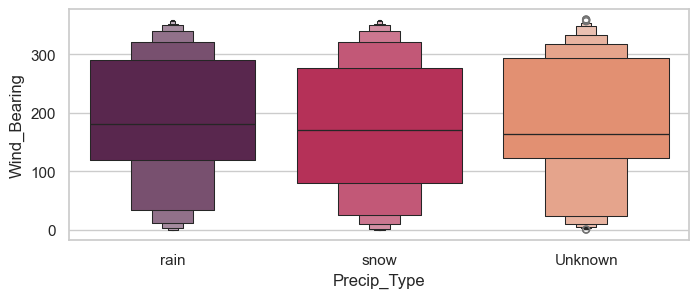

In [40]:
sns.boxenplot(data=weather,x='Precip_Type',y='Wind_Bearing',palette='rocket')

<Axes: xlabel='Precip_Type', ylabel='Wind_Speed'>

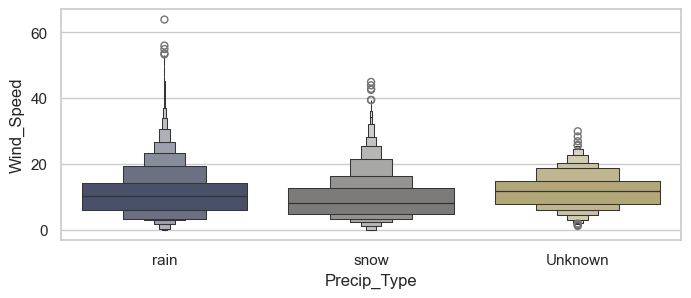

In [41]:
sns.boxenplot(data=weather,x='Precip_Type',y='Wind_Speed',palette='cividis')

<Axes: xlabel='Precip_Type', ylabel='Visibility'>

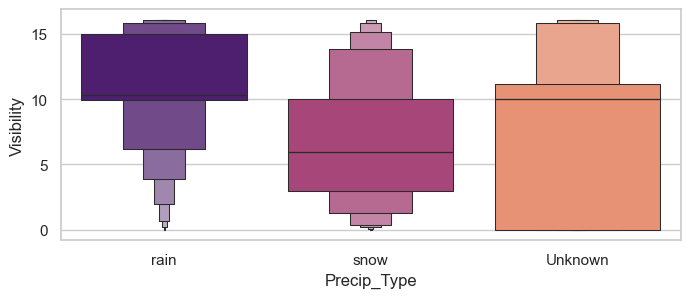

In [42]:
sns.boxenplot(data=weather,x='Precip_Type',y='Visibility',palette='magma')

In [43]:
weather.head()

,Formatted_Date,Summary,Precip_Type,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Loud_Cover,Pressure,Daily_Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


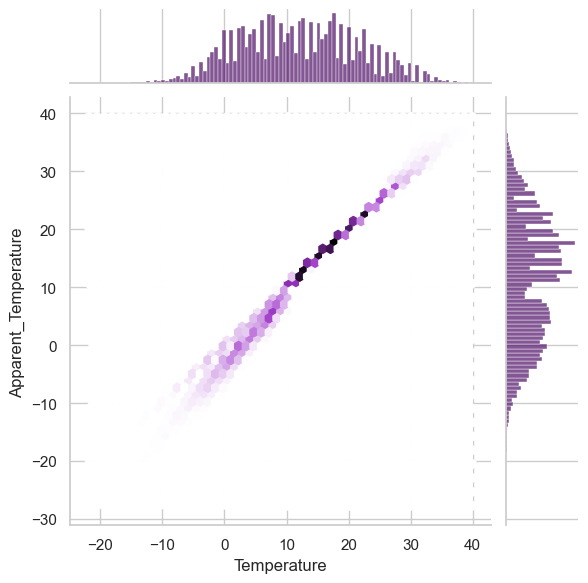

In [44]:
sns.jointplot(data=weather,x='Temperature',y='Apparent_Temperature',color='m',kind='hex')

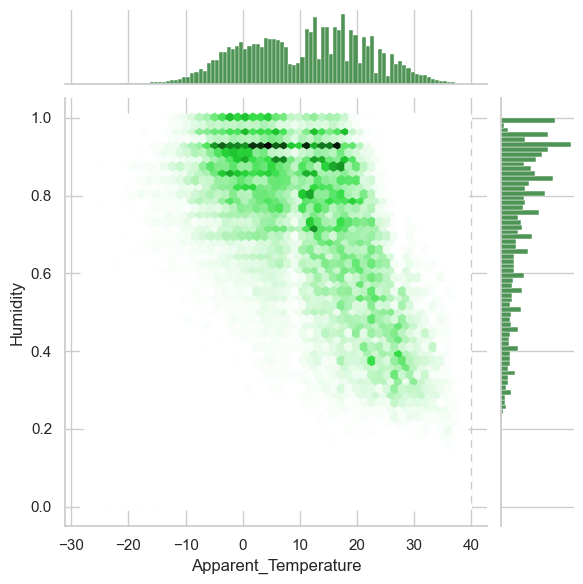

In [45]:
sns.jointplot(data=weather,x='Apparent_Temperature',y='Humidity',color='g',kind='hex')

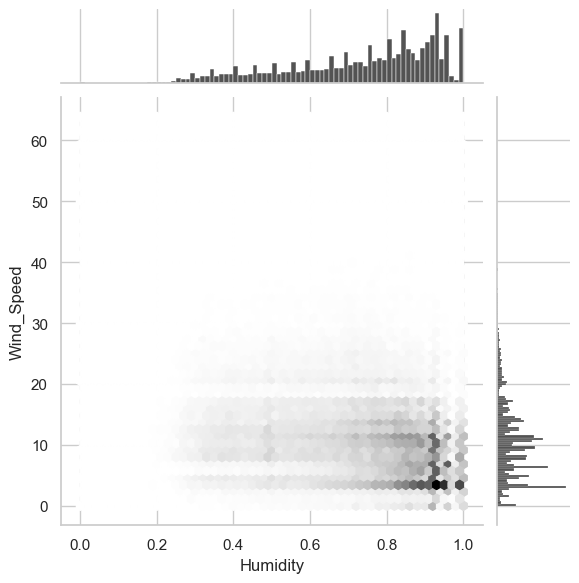

In [46]:
sns.jointplot(data=weather,x='Humidity',y='Wind_Speed',color='k',kind='hex')

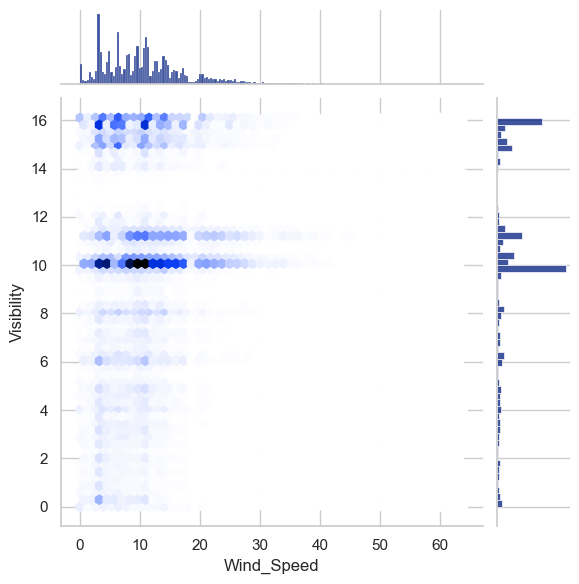

In [47]:
sns.jointplot(data=weather,x='Wind_Speed',y='Visibility',color='b',kind='hex')

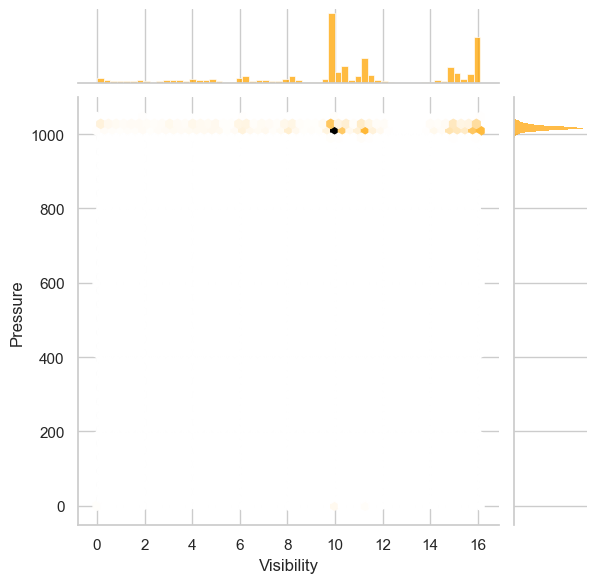

In [48]:
sns.jointplot(data=weather,x='Visibility',y='Pressure',color='orange',kind='hex')

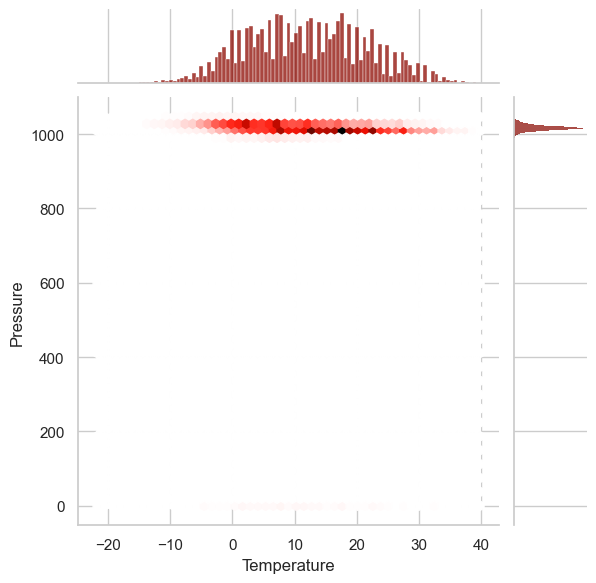

In [49]:
sns.jointplot(data=weather,x='Temperature',y='Pressure',color='r',kind='hex')

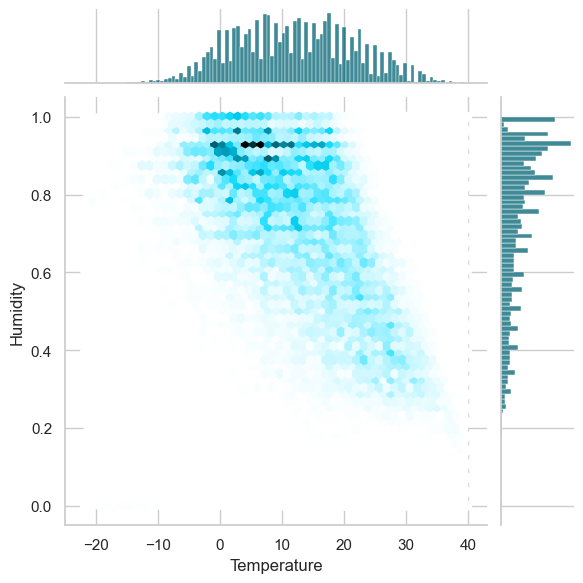

In [50]:
sns.jointplot(data=weather,x='Temperature',y='Humidity',color='c',kind='hex')

In [51]:
weather.head()

,Formatted_Date,Summary,Precip_Type,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Loud_Cover,Pressure,Daily_Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


<Axes: xlabel='Precip_Type', ylabel='Temperature'>

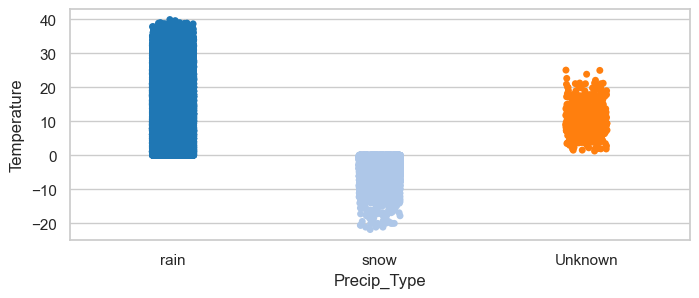

In [52]:
sns.stripplot(data=weather,x='Precip_Type',y='Temperature',palette='tab20')

<Axes: xlabel='Precip_Type', ylabel='Apparent_Temperature'>

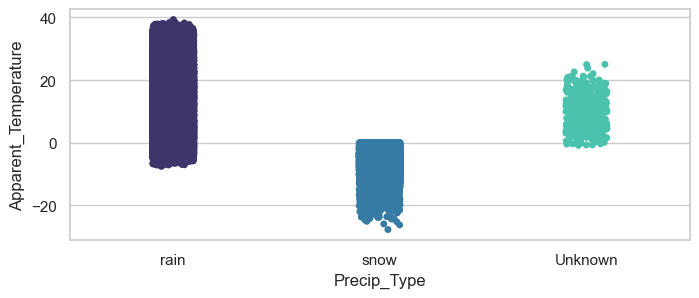

In [53]:
sns.stripplot(data=weather,x='Precip_Type',y='Apparent_Temperature',palette='mako')

<Axes: xlabel='Precip_Type', ylabel='Humidity'>

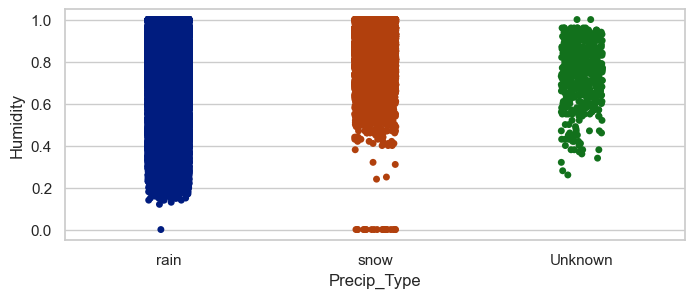

In [54]:
sns.stripplot(data=weather,x='Precip_Type',y='Humidity',palette='dark')

<Axes: xlabel='Precip_Type', ylabel='Wind_Speed'>

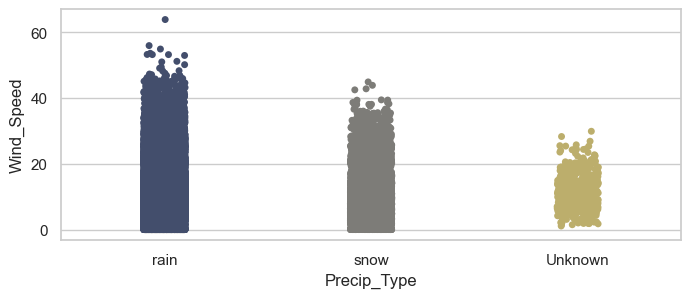

In [55]:
sns.stripplot(data=weather,x='Precip_Type',y='Wind_Speed',palette='cividis')

<Axes: xlabel='Precip_Type', ylabel='Wind_Bearing'>

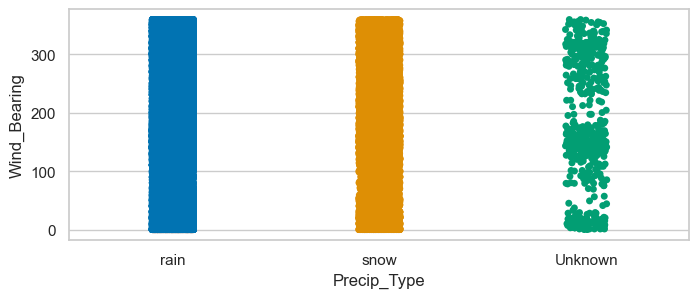

In [56]:
sns.stripplot(data=weather,x='Precip_Type',y='Wind_Bearing',palette='colorblind')

<Axes: xlabel='Precip_Type', ylabel='Visibility'>

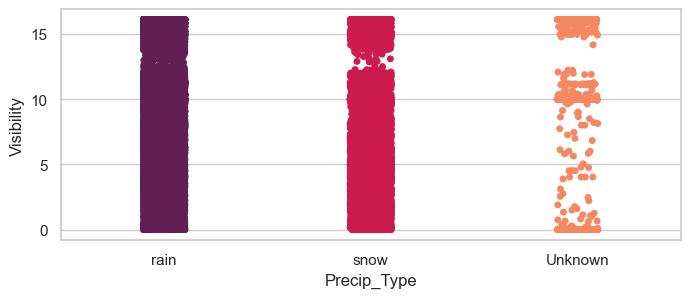

In [57]:
sns.stripplot(data=weather,x='Precip_Type',y='Visibility',palette='rocket')

In [58]:
weather.head()

,Formatted_Date,Summary,Precip_Type,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Loud_Cover,Pressure,Daily_Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


<Axes: xlabel='Temperature', ylabel='Density'>

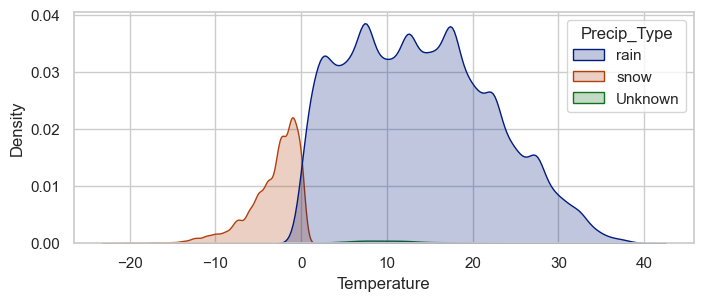

In [59]:
sns.kdeplot(data=weather,x='Temperature',hue='Precip_Type',palette='dark',fill=True)

<Axes: xlabel='Apparent_Temperature', ylabel='Density'>

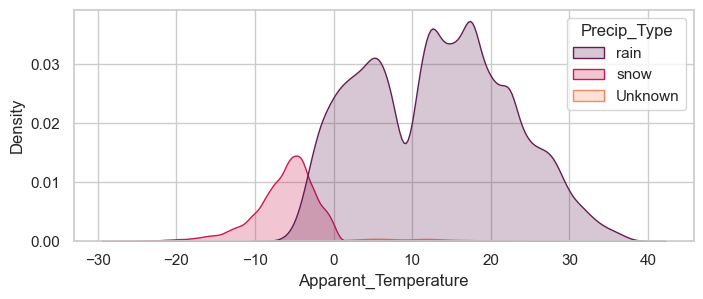

In [60]:
sns.kdeplot(data=weather,x='Apparent_Temperature',hue='Precip_Type',palette='rocket',fill=True)

<Axes: xlabel='Humidity', ylabel='Density'>

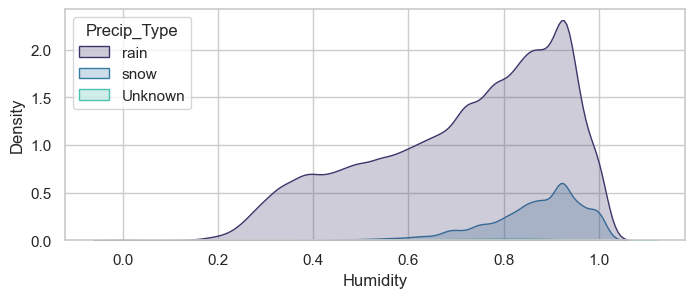

In [61]:
sns.kdeplot(data=weather,x='Humidity',hue='Precip_Type',palette='mako',fill=True)

<Axes: xlabel='Wind_Speed', ylabel='Density'>

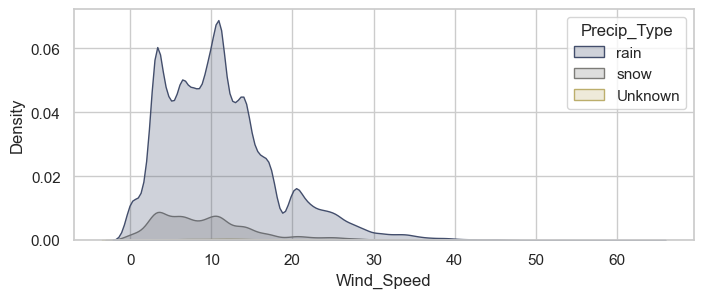

In [62]:
sns.kdeplot(data=weather,x='Wind_Speed',hue='Precip_Type',palette='cividis',fill=True)

<Axes: xlabel='Wind_Bearing', ylabel='Density'>

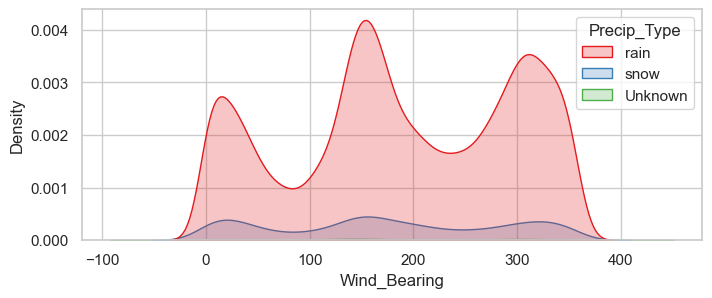

In [63]:
sns.kdeplot(data=weather,x='Wind_Bearing',hue='Precip_Type',palette='Set1',fill=True)

<Axes: xlabel='Visibility', ylabel='Density'>

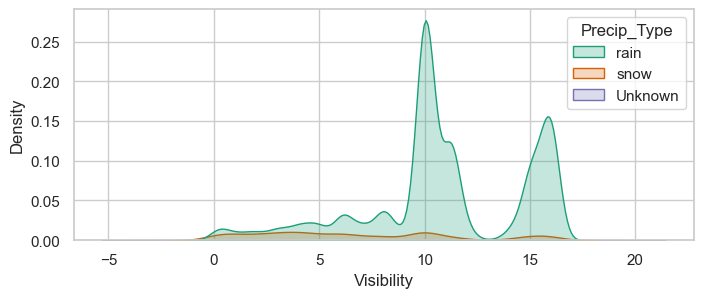

In [64]:
sns.kdeplot(data=weather,x='Visibility',hue='Precip_Type',palette='Dark2',fill=True)

<Axes: xlabel='Pressure', ylabel='Density'>

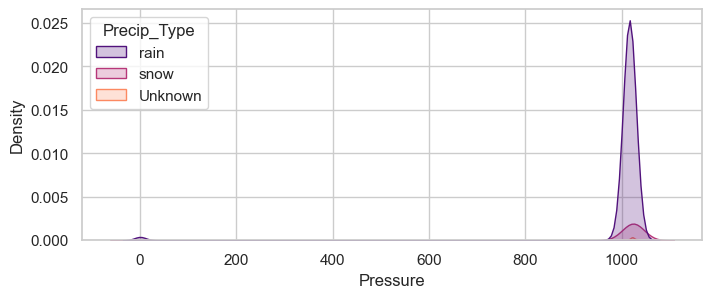

In [65]:
sns.kdeplot(data=weather,x='Pressure',hue='Precip_Type',palette='magma',fill=True)

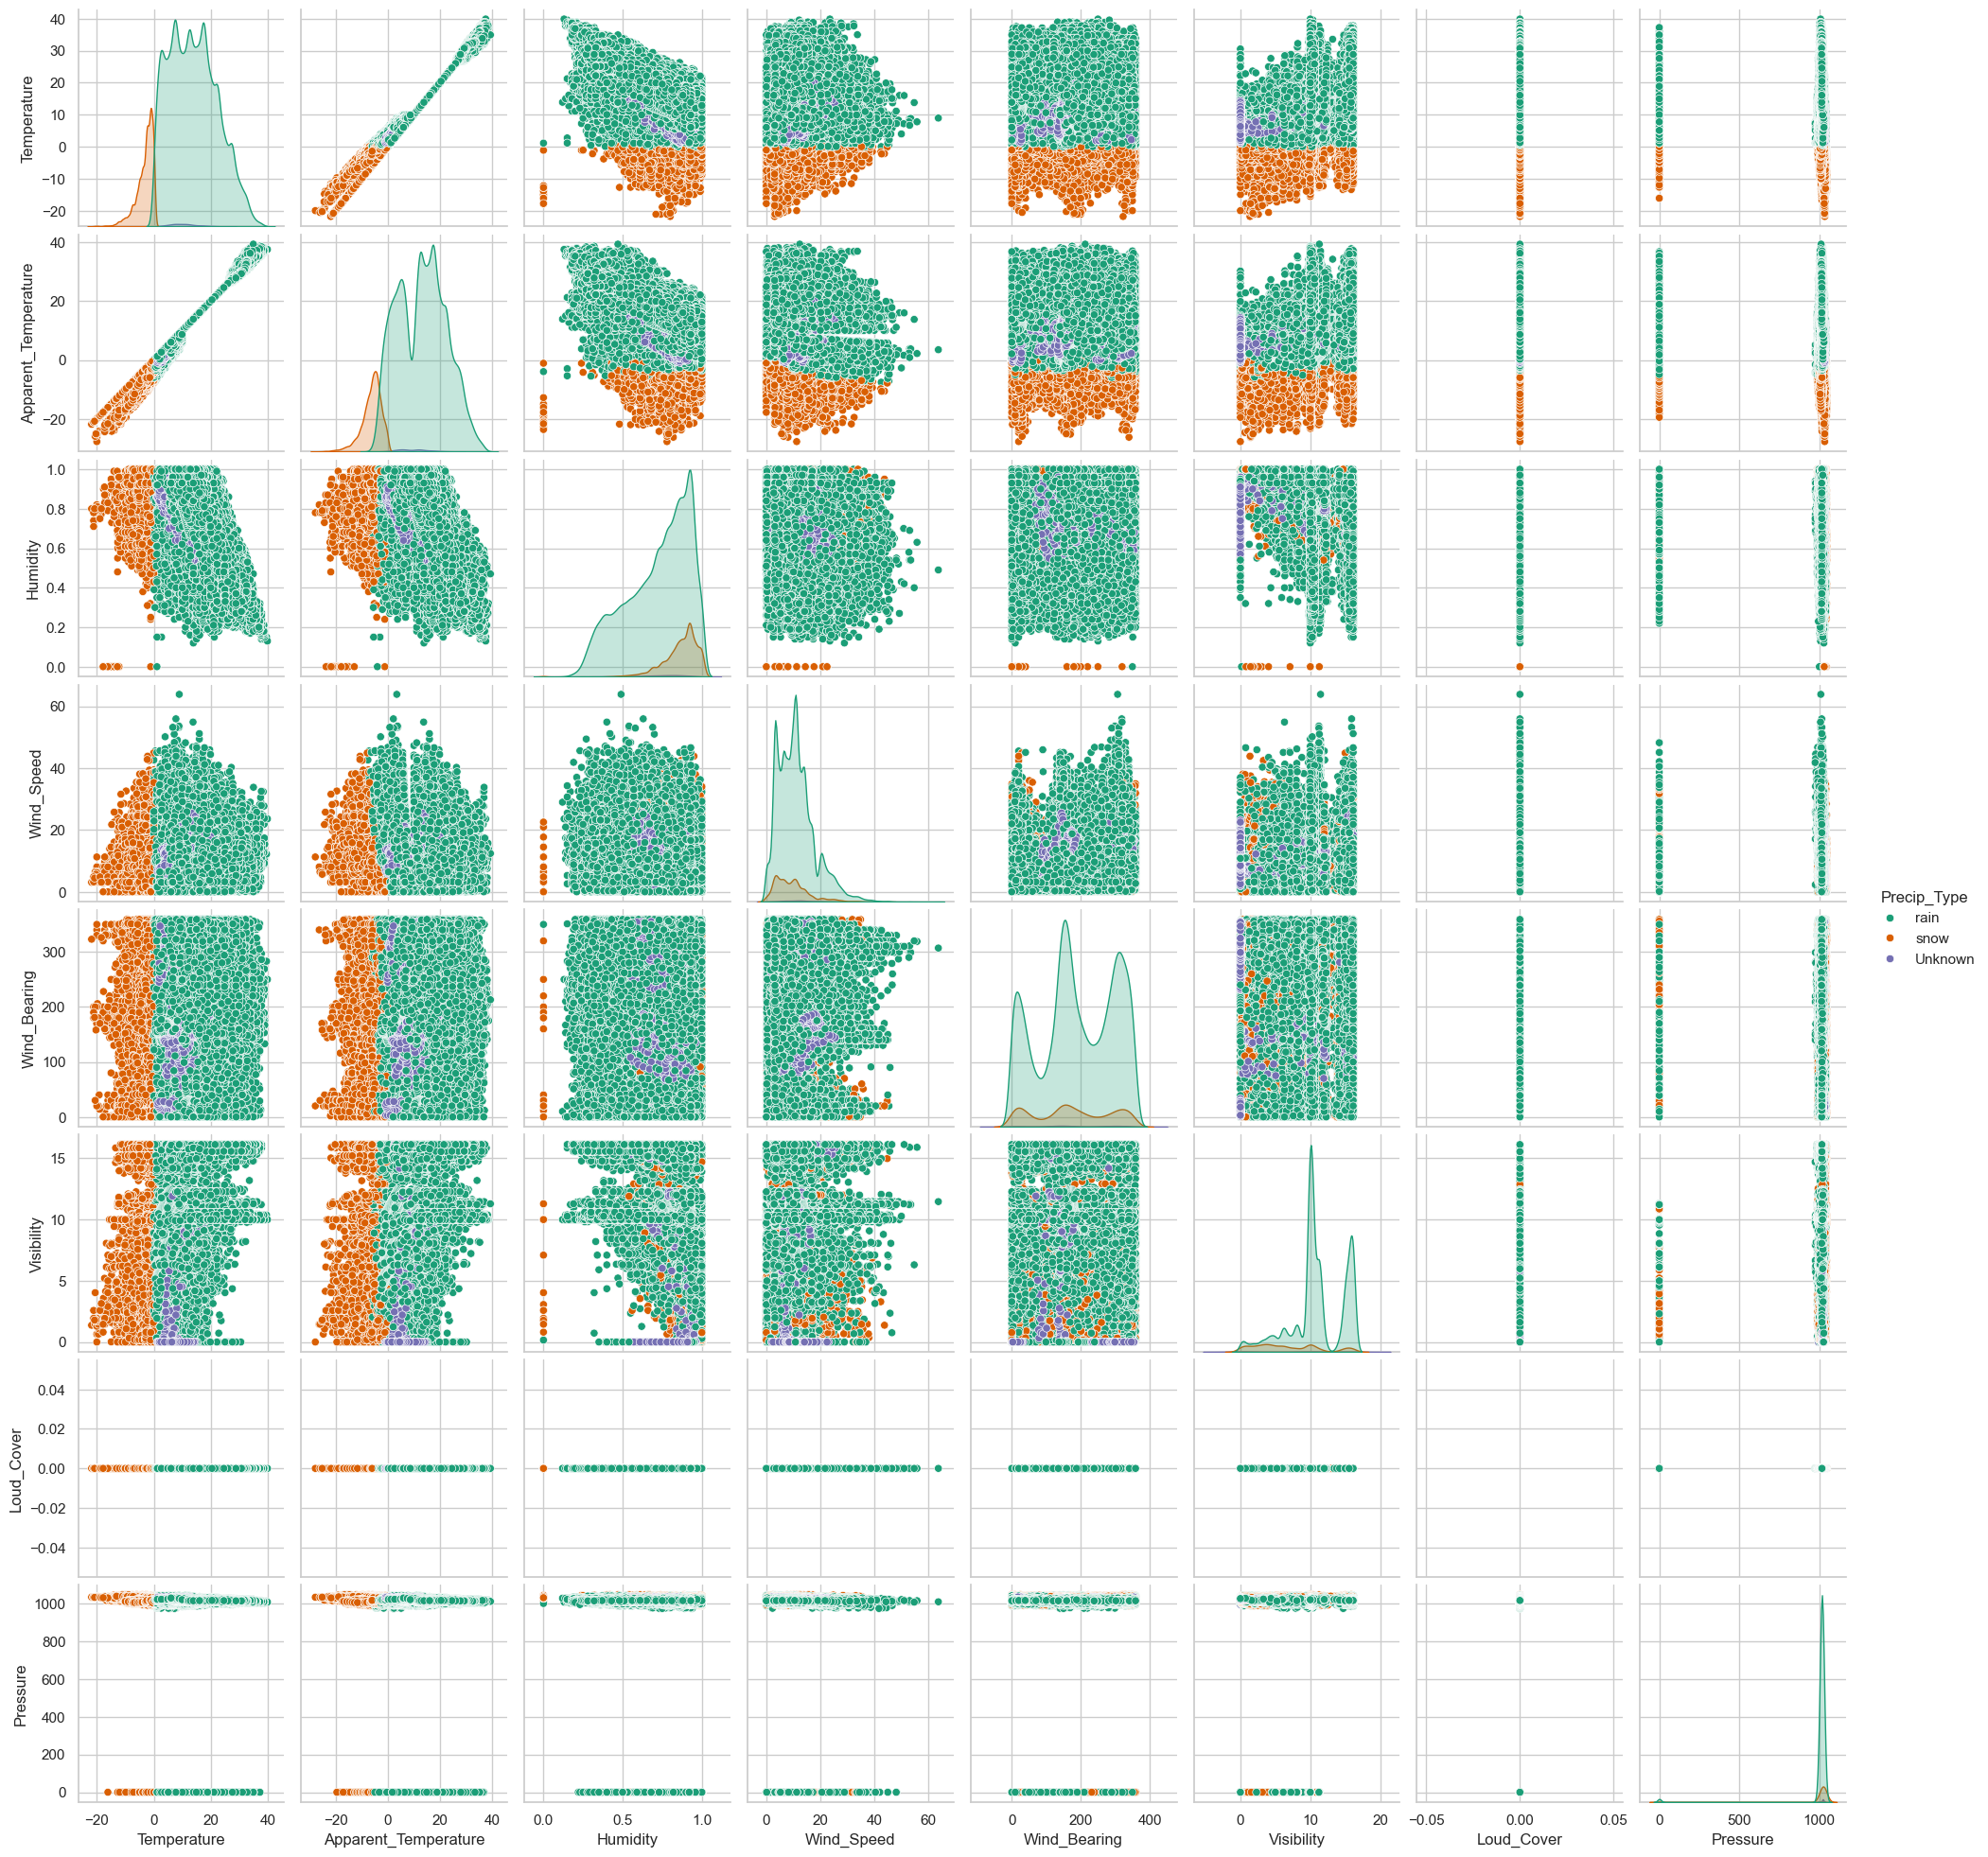

In [66]:
sns.pairplot(weather,hue="Precip_Type",palette='Dark2')